# Q dependence: 320–350 K

Fast $\tau$ and $\beta$ versus $Q_0$ for the four temperatures that have all four reflections.
Low $\rightarrow$ high $Q$: (011), (10-1), (120), (101).

Reads the saved `qdep_T*K.h5` files. Colors are locked **turbo** (`temperature_color`).

To plot $\tau(T)$ for one peak, change `REFLECTION` in the last section and re-run that cell.

In [1]:
import sys
sys.path.append('../src/')

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

from postprocess import (
    REFLECTION_ORDER,
    discover_qdep_files,
    load_temperature_qdep,
    reflection_series,
    temperature_cmap,
    temperature_color,
    temperature_norm,
)

In [27]:
def apply_paper_style():
    helvetica = font_manager.FontProperties(family='Helvetica')
    font_manager.findfont(helvetica, fallback_to_default=False)
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Helvetica', 'Arial'],
        'font.size': 9,
        'axes.labelsize': 11,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'legend.frameon': False,
        'axes.linewidth': 1.0,
        'lines.linewidth': 1.3,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.major.width': 1.0,
        'ytick.major.width': 1.0,
        'xtick.major.size': 4.5,
        'ytick.major.size': 4.5,
        'xtick.top': True,
        'ytick.right': True,
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Helvetica',
        'mathtext.it': 'Helvetica:italic',
        'mathtext.bf': 'Helvetica:bold',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.03,
    })


apply_paper_style()

cmap = temperature_cmap()
norm = temperature_norm()
FIGSIZE = (8.8, 3.7)
TDEP_FIGSIZE = (4.6, 3.7)
SHOW_POWER_LAWS = True

MARKERS = {
    '011': 'o',
    '10-1': 's',
    '120': 'D',
    '101': '^',
    '111': '*',
}
HKL_COLORS = {
    '011': '#2E5E8C',
    '10-1': '#2F8A6B',
    '120': '#C97A2B',
    '101': '#9E3B4E',
}
Q_XLIM = (1.07, 1.17)

In [28]:
config_path = Path('../configs/config_B10.json')
config = json.loads(config_path.read_text()) if config_path.exists() else {}
base = Path(config['Base']) if config.get('Base') else Path('/Users/eriklamb/data/APS/8_ID_E/Na2B10H10')

rows = [load_temperature_qdep(p) for p in discover_qdep_files(base)]
qdep = [r for r in rows if len(r['reflection']) > 1]

print('four-peak Q-dependence')
print(f"{'T':>5} {'hkl':>6} {'Q0':>8} {'tau_fast':>12} {'d_tau':>10} {'beta':>8} {'d_beta':>8}")
for row in qdep:
    for lab, q, tau, te, beta, be in zip(
        row['reflection'], row['Q0'], row['tau_fast'], row['tau_fast_err'],
        row['beta_fast'], row['beta_fast_err'],
    ):
        print(
            f"{row['temperature']:5.0f} ({lab:>4}) {q:8.5f} "
            f"{tau:12.4g} {te:10.3g} {beta:8.3f} {be:8.3g}"
        )

four-peak Q-dependence
    T    hkl       Q0     tau_fast      d_tau     beta   d_beta
  320 ( 011)  1.08183        44.59       3.52    1.075    0.102
  320 (10-1)  1.10494        25.19       1.06    0.603   0.0572
  320 ( 120)  1.14078        11.22       4.59    0.664   0.0621
  320 ( 101)  1.15817        18.74       10.8    1.459    0.671
  329 ( 011)  1.08015        26.89       1.24    1.527    0.111
  329 (10-1)  1.10321        15.13        1.2    1.217    0.142
  329 ( 120)  1.13921        44.19       4.56    0.894   0.0591
  329 ( 101)  1.15719        67.67       14.1    0.642   0.0743
  339 ( 011)  1.08020        13.22      0.526    1.256   0.0955
  339 (10-1)  1.11543        9.399      0.657    1.167   0.0869
  339 ( 120)  1.13364        9.875      0.278    0.939   0.0775
  339 ( 101)  1.15097        19.96       3.03    0.828    0.224
  350 ( 011)  1.07955        13.25      0.728    0.974   0.0464
  350 (10-1)  1.11426        8.515      0.142    1.277   0.0615
  350 ( 120)  1.1

# $\tau_\mathrm{fast}(Q)$ and $\beta_\mathrm{fast}(Q)$

One series per temperature. Set `SHOW_POWER_LAWS = False` in the style cell to drop the $Q^{-1}$ / $Q^{-2}$ guides.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


saved ../figures/qdep_four_temps.pdf


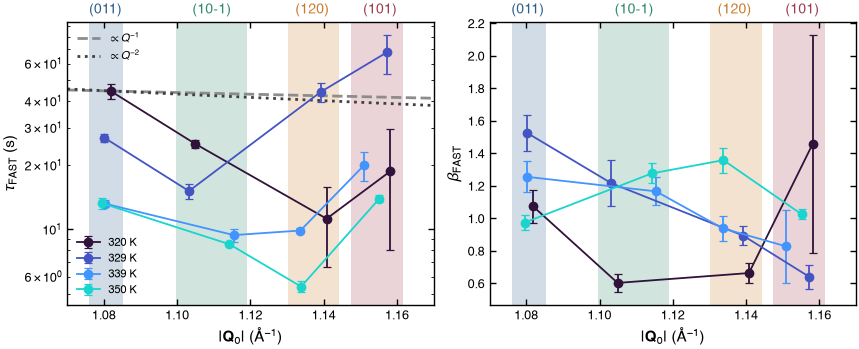

In [35]:
HKL_COLORS = {
    '011': '#2E5E8C',
    '10-1': '#2F8A6B',
    '120': '#C97A2B',
    '101': '#9E3B4E',
}
Q_XLIM = (1.07, 1.17)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
ax_t, ax_b = axes

qs_by_hkl = {}
for row in qdep:
    for lab, q in zip(row['reflection'], row['Q0']):
        qs_by_hkl.setdefault(lab, []).append(float(q))
hkl_order = [lab for lab, _ in sorted(qs_by_hkl.items(), key=lambda kv: np.mean(kv[1]))]

def pale_hex(hex_color, mix=0.78):
    h = hex_color.lstrip('#')
    r, g, b = (int(h[i:i + 2], 16) / 255.0 for i in (0, 2, 4))
    return (r + (1.0 - r) * mix, g + (1.0 - g) * mix, b + (1.0 - b) * mix)

pad = 0.0035
for ax in (ax_t, ax_b):
    ax.patch.set_facecolor('white')
    ax.patch.set_zorder(-1)
    for lab in hkl_order:
        qs = qs_by_hkl[lab]
        ax.axvspan(
            min(qs) - pad, max(qs) + pad,
            facecolor=pale_hex(HKL_COLORS[lab]), edgecolor='none',
            zorder=0, lw=0,
        )

q_lines = []
if SHOW_POWER_LAWS and qdep:
    q0 = np.asarray(qdep[0]['Q0'], dtype=float)
    tau0 = np.asarray(qdep[0]['tau_fast'], dtype=float)
    ok = np.isfinite(q0) & np.isfinite(tau0) & (q0 > 0) & (tau0 > 0)
    q_ref, tau_ref = float(q0[ok][0]), float(tau0[ok][0])
    q_line = np.linspace(1.07, 1.17, 200)
    q_lines += ax_t.plot(q_line, tau_ref * (q_ref / q_line), '--', color='0.55',
                         lw=2.0, label=r'$\propto Q^{-1}$', zorder=2)
    q_lines += ax_t.plot(q_line, tau_ref * (q_ref / q_line) ** 2, ':', color='0.25',
                         lw=2.0, label=r'$\propto Q^{-2}$', zorder=2)

temp_handles = []
for row in qdep:
    T = row['temperature']
    color = temperature_color(T, cmap=cmap, norm=norm)
    temp_handles.append(ax_t.errorbar(
        row['Q0'], row['tau_fast'], yerr=row['tau_fast_err'],
        fmt='o-', color=color, ecolor=color, capsize=3, capthick=0.9,
        markersize=6, label=f'{T:g} K', zorder=3,
    ))
    ax_b.errorbar(
        row['Q0'], row['beta_fast'], yerr=row['beta_fast_err'],
        fmt='o-', color=color, ecolor=color, capsize=3, capthick=0.9,
        markersize=6, label=f'{T:g} K', zorder=3,
    )

ax_t.set_yscale('log')

for ax in (ax_t, ax_b):
    ymin, ymax = ax.get_ylim()
    for lab in hkl_order:
        qmid = float(np.mean(qs_by_hkl[lab]))
        ax.annotate(
            f'({lab})', (qmid, ymax), textcoords='offset points', xytext=(0, 4),
            ha='center', va='bottom', fontsize=10, color=HKL_COLORS[lab],
        )

ax_t.set_xlabel(r'$|\mathbf{Q}_0|$ (Å$^{-1}$)')
ax_t.set_ylabel(r'$\tau_\mathrm{FAST}$ (s)')
ax_t.set_xlim(*Q_XLIM)
if q_lines:
    ax_t.add_artist(ax_t.legend(handles=q_lines, loc='upper left'))
ax_t.legend(handles=temp_handles, loc='lower left')

ax_b.set_xlabel(r'$|\mathbf{Q}_0|$ (Å$^{-1}$)')
ax_b.set_ylabel(r'$\beta_\mathrm{FAST}$')
ax_b.set_xlim(*Q_XLIM)
#ax_b.legend(loc='best')

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'qdep_four_temps.pdf')
fig.savefig(out / 'qdep_four_temps.png')
print('saved', out / 'qdep_four_temps.pdf')

# Arrhenius: all four peaks

$\ln\tau_\mathrm{fast}$ vs $1000/T$ for (011), (10-1), (120), and (101). Line and marker colors match the $Q$-dependence bands.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(011)  Ea = 0.358 ± 0.228 eV  (34.5 kJ/mol)  tau0 = 7.68e-05 s
  T      [320. 329. 339. 350.]
  1000/T [3.125      3.03951368 2.94985251 2.85714286]
  ln tau [3.79761885 3.29172202 2.58150472 2.58405535]
(10-1)  Ea = 0.229 ± 0.081 eV  (22.1 kJ/mol)  tau0 = 0.00423 s
  T      [320. 329. 339. 350.]
  1000/T [3.125      3.03951368 2.94985251 2.85714286]
  ln tau [3.22629746 2.71666676 2.24058618 2.14183704]
(120)  Ea = 0.809 ± 0.347 eV  (78.0 kJ/mol)  tau0 = 1.02e-11 s
  T      [320. 329. 339. 350.]
  1000/T [3.125      3.03951368 2.94985251 2.85714286]
  ln tau [2.41738985 3.78852906 2.29000523 1.683955  ]
(101)  Ea = 0.617 ± 0.200 eV  (59.6 kJ/mol)  tau0 = 1.77e-08 s
  T      [320. 329. 339. 350.]
  1000/T [3.125      3.03951368 2.94985251 2.85714286]
  ln tau [2.93060105 4.21458999 2.99393388 2.6327297 ]
saved ../figures/arrhenius_all_four_peak.pdf


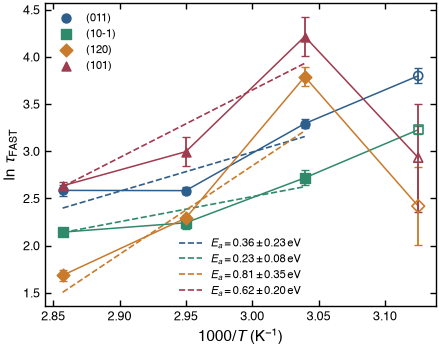

In [44]:
HKL_COLORS = {
    '011': '#2E5E8C',
    '10-1': '#2F8A6B',
    '120': '#C97A2B',
    '101': '#9E3B4E',
}
kB_eV = 8.617333262145e-5   # eV / K
R_kJ = 8.314462618e-3       # kJ / mol / K

series_list = [reflection_series(rows, lab) for lab in REFLECTION_ORDER]
series_list = [s for s in series_list if s['temperature'].size]
if not series_list:
    raise ValueError('no four-peak qdep points')

fig, ax = plt.subplots(figsize=TDEP_FIGSIZE)
fit_handles = []
peak_handles = []
for s in series_list:
    T = np.asarray(s['temperature'], dtype=float)
    tau = np.asarray(s['tau_fast'], dtype=float)
    dtau = np.asarray(s['tau_fast_err'], dtype=float)
    invT = 1000.0 / T
    ln_tau = np.log(tau)
    ln_err = np.full_like(tau, np.nan)
    ok_err = np.isfinite(tau) & (tau > 0) & np.isfinite(dtau) & (dtau > 0)
    ln_err[ok_err] = dtau[ok_err] / tau[ok_err]
    color = HKL_COLORS[s['reflection']]
    marker = MARKERS.get(s['reflection'], 'o')

    fit_ok = np.isfinite(invT) & np.isfinite(ln_tau) & (tau > 0) & (T != 320.0)
    if fit_ok.sum() >= 2:
        xfit, yfit = invT[fit_ok], ln_tau[fit_ok]
        w = ln_err[fit_ok]
        fit_kw = {'cov': True}
        if np.all(np.isfinite(w) & (w > 0)):
            fit_kw['w'] = 1.0 / w
        (slope, intercept), cov = np.polyfit(xfit, yfit, 1, **fit_kw)
        Ea_eV = slope * 1000.0 * kB_eV
        Ea_err = float(np.sqrt(cov[0, 0])) * 1000.0 * kB_eV
        Ea_kJ = slope * 1000.0 * R_kJ
        x_line = np.linspace(xfit.min(), xfit.max(), 50)
        fit_line, = ax.plot(
            x_line, slope * x_line + intercept, '--', color=color, lw=1.2, zorder=2,
            label=rf'$E_a={Ea_eV:.2f}\pm{Ea_err:.2f}\,\mathrm{{eV}}$',
        )
        fit_handles.append(fit_line)
        print(
            f"({s['reflection']})  Ea = {Ea_eV:.3f} ± {Ea_err:.3f} eV  "
            f"({Ea_kJ:.1f} kJ/mol)  tau0 = {np.exp(intercept):.3g} s"
        )
    print(f"  T      {T}")
    print(f"  1000/T {invT}")
    print(f"  ln tau {ln_tau}")

    ax.errorbar(invT, ln_tau, yerr=ln_err, fmt='none', ecolor=color, capsize=3, zorder=3)
    ax.plot(invT, ln_tau, '-', color=color, lw=1.1, zorder=3)
    open_pt = np.isclose(T, 320.0)
    peak_handles.append(ax.scatter(
        invT[~open_pt], ln_tau[~open_pt], color=color, marker=marker, s=42,
        zorder=4, label=f"({s['reflection']})",
    ))
    ax.scatter(
        invT[open_pt], ln_tau[open_pt], facecolors='none', edgecolors=color,
        marker=marker, s=42, linewidths=1.2, zorder=4,
    )

ax.set_xlabel(r'$1000/T$ (K$^{-1}$)')
ax.set_ylabel(r'$\ln\,\tau_\mathrm{FAST}$')
peak_leg = ax.legend(handles=peak_handles, loc='best')
ax.add_artist(peak_leg)
if fit_handles:
    ax.legend(handles=fit_handles, loc='lower center')

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'arrhenius_all_four_peak.pdf')
fig.savefig(out / 'arrhenius_all_four_peak.png')
print('saved', out / 'arrhenius_all_four_peak.pdf')

# Arrhenius: (011) and (10-1)

Same axes and colors as the four-peak figure, only the two lowest-$Q$ reflections.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(011)  Ea = 0.415 ± 0.137 eV  (40.0 kJ/mol)  tau0 = 1.11e-05 s
(10-1)  Ea = 0.335 ± 0.041 eV  (32.3 kJ/mol)  tau0 = 0.000128 s
saved ../figures/arrhenius_011_10m1.pdf


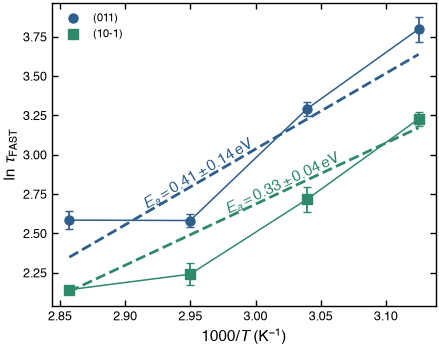

In [41]:
HKL_COLORS = {
    '011': '#2E5E8C',
    '10-1': '#2F8A6B',
    '120': '#C97A2B',
    '101': '#9E3B4E',
}
kB_eV = 8.617333262145e-5
R_kJ = 8.314462618e-3
HKL_PAIR = ('011', '10-1')

series_pair = [reflection_series(rows, lab) for lab in HKL_PAIR]
series_pair = [s for s in series_pair if s['temperature'].size]
if not series_pair:
    raise ValueError('no qdep points for (011) / (10-1)')

fig, ax = plt.subplots(figsize=TDEP_FIGSIZE)
fits = []
for s in series_pair:
    T = np.asarray(s['temperature'], dtype=float)
    tau = np.asarray(s['tau_fast'], dtype=float)
    dtau = np.asarray(s['tau_fast_err'], dtype=float)
    invT = 1000.0 / T
    ln_tau = np.log(tau)
    ln_err = np.full_like(tau, np.nan)
    ok_err = np.isfinite(tau) & (tau > 0) & np.isfinite(dtau) & (dtau > 0)
    ln_err[ok_err] = dtau[ok_err] / tau[ok_err]
    color = HKL_COLORS[s['reflection']]
    marker = MARKERS.get(s['reflection'], 'o')

    fit_ok = np.isfinite(invT) & np.isfinite(ln_tau) & (tau > 0)
    if fit_ok.sum() >= 2:
        xfit, yfit = invT[fit_ok], ln_tau[fit_ok]
        w = ln_err[fit_ok]
        fit_kw = {'cov': True}
        if np.all(np.isfinite(w) & (w > 0)):
            fit_kw['w'] = 1.0 / w
        (slope, intercept), cov = np.polyfit(xfit, yfit, 1, **fit_kw)
        Ea_eV = slope * 1000.0 * kB_eV
        Ea_err = float(np.sqrt(cov[0, 0])) * 1000.0 * kB_eV
        Ea_kJ = slope * 1000.0 * R_kJ
        x_line = np.linspace(xfit.min(), xfit.max(), 50)
        ax.plot(x_line, slope * x_line + intercept, '--', color=color, lw=2, zorder=2)
        fits.append((slope, intercept, Ea_eV, Ea_err, color, xfit))
        print(
            f"({s['reflection']})  Ea = {Ea_eV:.3f} ± {Ea_err:.3f} eV  "
            f"({Ea_kJ:.1f} kJ/mol)  tau0 = {np.exp(intercept):.3g} s"
        )

    ax.errorbar(invT, ln_tau, yerr=ln_err, fmt='none', ecolor=color, capsize=3, zorder=3)
    ax.plot(invT, ln_tau, '-', color=color, lw=1.1, zorder=3)
    ax.scatter(
        invT, ln_tau, color=color, marker=marker, s=42, zorder=4,
        label=f"({s['reflection']})",
    )

ax.set_xlabel(r'$1000/T$ (K$^{-1}$)')
ax.set_ylabel(r'$\ln\,\tau_\mathrm{FAST}$')
ax.legend(loc='best')
fig.canvas.draw()

fracs = np.linspace(0.38, 0.62, max(len(fits), 1))
for (slope, intercept, Ea_eV, Ea_err, color, xfit), frac in zip(fits, fracs):
    x0 = (1.0 - frac) * xfit.min() + frac * xfit.max()
    y0 = slope * x0 + intercept
    p0 = ax.transData.transform((0.0, 0.0))
    p1 = ax.transData.transform((1.0, slope))
    angle = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
    ax.text(
        x0, y0, rf'$E_a={Ea_eV:.2f}\pm{Ea_err:.2f}\,\mathrm{{eV}}$',
        color=color, rotation=angle, rotation_mode='anchor',
        ha='center', va='bottom', fontsize=plt.rcParams['axes.labelsize'], zorder=5,
    )

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'arrhenius_011_10m1.pdf')
fig.savefig(out / 'arrhenius_011_10m1.png')
print('saved', out / 'arrhenius_011_10m1.pdf')

# Arrhenius: four peaks + (111)

Same two-legend layout, now \(1/\tau_\mathrm{FAST}\) vs \(1000/T\) on a log y-axis. Width matches `qdep_four_temps.pdf`. (111) is purple and unfitted; 320 K stays open-faced and is left out of the four-peak fits.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


(011)  Ea = 0.358 ± 0.228 eV  (34.5 kJ/mol)  tau0 = 7.68e-05 s
(10-1)  Ea = 0.229 ± 0.081 eV  (22.1 kJ/mol)  tau0 = 0.00423 s
(120)  Ea = 0.809 ± 0.347 eV  (78.0 kJ/mol)  tau0 = 1.02e-11 s
(101)  Ea = 0.617 ± 0.200 eV  (59.6 kJ/mol)  tau0 = 1.77e-08 s
saved ../figures/arrhenius_all_peaks.pdf


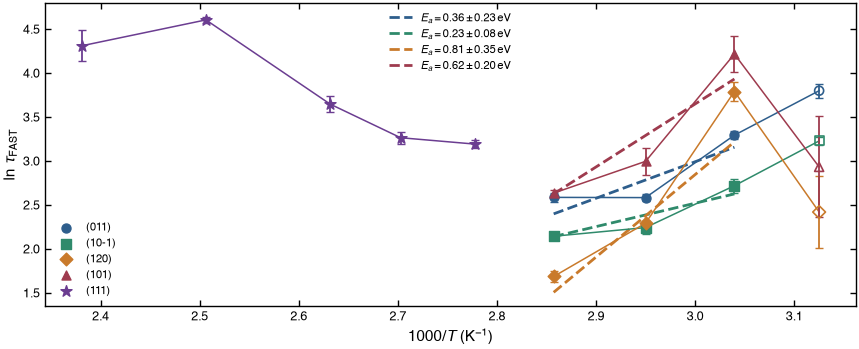

In [51]:
HKL_COLORS = {
    '011': '#2E5E8C',
    '10-1': '#2F8A6B',
    '120': '#C97A2B',
    '101': '#9E3B4E',
    '111': '#6B3D91',
}
kB_eV = 8.617333262145e-5
R_kJ = 8.314462618e-3
HKL_ALL = REFLECTION_ORDER + ('111',)

series_list = [reflection_series(rows, lab) for lab in HKL_ALL]
series_list = [s for s in series_list if s['temperature'].size]
if not series_list:
    raise ValueError('no qdep points for Arrhenius plot')

fig, ax = plt.subplots(figsize=FIGSIZE)
fit_handles = []
peak_handles = []
for s in series_list:
    T = np.asarray(s['temperature'], dtype=float)
    tau = np.asarray(s['tau_fast'], dtype=float)
    dtau = np.asarray(s['tau_fast_err'], dtype=float)
    invT = 1000.0 / T
    rate = np.full_like(tau, np.nan)
    ok_tau = np.isfinite(tau) & (tau > 0)
    rate[ok_tau] = 1.0 / tau[ok_tau]
    ln_tau = np.log(tau, where=ok_tau, out=np.full_like(tau, np.nan))
    rate_err = np.full_like(tau, np.nan)
    ln_err = np.full_like(tau, np.nan)
    ok_err = ok_tau & np.isfinite(dtau) & (dtau > 0)
    rate_err[ok_err] = dtau[ok_err] / tau[ok_err] ** 2
    ln_err[ok_err] = dtau[ok_err] / tau[ok_err]
    color = HKL_COLORS[s['reflection']]
    marker = MARKERS.get(s['reflection'], 'o')
    msize = 70 if s['reflection'] == '111' else 42

    if s['reflection'] != '111':
        fit_ok = np.isfinite(invT) & np.isfinite(ln_tau) & ok_tau & (T != 320.0)
        if fit_ok.sum() >= 2:
            xfit, yfit = invT[fit_ok], ln_tau[fit_ok]
            w = ln_err[fit_ok]
            fit_kw = {'cov': True}
            if np.all(np.isfinite(w) & (w > 0)):
                fit_kw['w'] = 1.0 / w
            (slope, intercept), cov = np.polyfit(xfit, yfit, 1, **fit_kw)
            Ea_eV = slope * 1000.0 * kB_eV
            Ea_err = float(np.sqrt(cov[0, 0])) * 1000.0 * kB_eV
            Ea_kJ = slope * 1000.0 * R_kJ
            x_line = np.linspace(xfit.min(), xfit.max(), 50)
            fit_line, = ax.plot(
                x_line, np.exp(-(slope * x_line + intercept)), '--', color=color, lw=2, zorder=2,
                label=rf'$E_a={Ea_eV:.2f}\pm{Ea_err:.2f}\,\mathrm{{eV}}$',
            )
            fit_handles.append(fit_line)
            print(
                f"({s['reflection']})  Ea = {Ea_eV:.3f} ± {Ea_err:.3f} eV  "
                f"({Ea_kJ:.1f} kJ/mol)  tau0 = {np.exp(intercept):.3g} s"
            )

    ax.errorbar(invT, rate, yerr=rate_err, fmt='none', ecolor=color, capsize=3, zorder=3)
    ax.plot(invT, rate, '-', color=color, lw=1.1, zorder=3)
    open_pt = np.isclose(T, 320.0) if s['reflection'] != '111' else np.zeros(T.shape, dtype=bool)
    peak_handles.append(ax.scatter(
        invT[~open_pt], rate[~open_pt], color=color, marker=marker, s=msize,
        zorder=4, label=f"({s['reflection']})",
    ))
    if open_pt.any():
        ax.scatter(
            invT[open_pt], rate[open_pt], facecolors='none', edgecolors=color,
            marker=marker, s=msize, linewidths=1.2, zorder=4,
        )

ax.set_yscale('log')
ax.set_xlabel(r'$1000/T$ (K$^{-1}$)')
ax.set_ylabel(r'$1/\tau_\mathrm{FAST}$ (s$^{-1}$)')
peak_leg = ax.legend(handles=peak_handles, loc='lower left', ncol=1)
ax.add_artist(peak_leg)
if fit_handles:
    ax.legend(handles=fit_handles, loc='upper right', ncol=1)

out = Path('../figures')
out.mkdir(exist_ok=True)
fig.tight_layout()
fig.savefig(out / 'arrhenius_all_peaks.pdf')
fig.savefig(out / 'arrhenius_all_peaks.png')
print('saved', out / 'arrhenius_all_peaks.pdf')
